import libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

download data

In [2]:
ticker = ["AAPL", "NVDA", "AMZN", "TSLA", "JPM"]

all_ticker_data = []

for ticker_symbol in ticker:

    ticker_data = yf.download(
        ticker_symbol,
        period="5y",
        auto_adjust=False
    )

    ticker_data.columns = ticker_data.columns.get_level_values(0)

    ticker_data = ticker_data.reset_index()

    ticker_data["Ticker"] = ticker_symbol

    all_ticker_data.append(ticker_data)

df = pd.concat(all_ticker_data, ignore_index=True)

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-09-13,145.866745,149.550003,151.419998,148.750000,150.630005,102404300,AAPL
1,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL
2,2021-09-15,145.359528,149.029999,149.440002,146.369995,148.559998,83281300,AAPL
3,2021-09-16,145.125473,148.789993,148.970001,147.220001,148.440002,68034100,AAPL
4,2021-09-17,142.462677,146.059998,148.820007,145.759995,148.820007,129868800,AAPL
...,...,...,...,...,...,...,...,...
6270,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM
6271,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM
6272,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM
6273,2026-09-10,353.559998,353.559998,354.220001,351.119995,353.510010,4184200,JPM


In [3]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-09-13,145.866745,149.550003,151.419998,148.750000,150.630005,102404300,AAPL
1,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL
2,2021-09-15,145.359528,149.029999,149.440002,146.369995,148.559998,83281300,AAPL
3,2021-09-16,145.125473,148.789993,148.970001,147.220001,148.440002,68034100,AAPL
4,2021-09-17,142.462677,146.059998,148.820007,145.759995,148.820007,129868800,AAPL


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6275 non-null   datetime64[ns]
 1   Adj Close  6275 non-null   float64       
 2   Close      6275 non-null   float64       
 3   High       6275 non-null   float64       
 4   Low        6275 non-null   float64       
 5   Open       6275 non-null   float64       
 6   Volume     6275 non-null   int64         
 7   Ticker     6275 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 392.3+ KB


In [5]:
df.describe()

Price,Date,Adj Close,Close,High,Low,Open,Volume
count,6275,6275.000000,6275.000000,6275.000000,6275.000000,6275.000000,6.275000e+03
mean,2024-03-11 12:38:26.294820608,190.288929,192.475068,195.253390,189.571815,192.442825,1.186288e+08
min,2021-09-13 00:00:00,11.186726,11.227000,11.735000,10.813000,10.971000,3.220500e+06
25%,2022-12-08 00:00:00,133.056107,138.324997,140.095001,136.639999,138.550003,3.448830e+07
50%,2024-03-12 00:00:00,182.574142,183.610001,185.899994,181.350006,183.809998,6.148000e+07
75%,2025-06-12 00:00:00,241.529999,243.845001,247.690002,240.540001,244.183334,1.222330e+08
max,2026-09-11 00:00:00,489.880005,489.880005,498.829987,485.329987,489.880005,1.543911e+09
std,NaN,92.230721,91.772948,93.390411,90.153438,91.808237,1.563320e+08


In [6]:
df.shape

(6275, 8)

In [7]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object', name='Price')

Question 1 — Overall performance

In [8]:
df1 = df[["Date", "Ticker", "Adj Close"]]
df1.columns = ['date', 'ticker', 'price']
df1


,date,ticker,price
0,2021-09-13,AAPL,145.866745
1,2021-09-14,AAPL,144.471970
2,2021-09-15,AAPL,145.359528
3,2021-09-16,AAPL,145.125473
4,2021-09-17,AAPL,142.462677
...,...,...,...
6270,2026-09-04,JPM,358.640015
6271,2026-09-08,JPM,353.510010
6272,2026-09-09,JPM,354.709991
6273,2026-09-10,JPM,353.559998


In [9]:
df1 = df1.pivot_table(index=['date'], columns='ticker', values=['price'])
df1.columns = [col[1] for col in df1.columns.values]
df1

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-09-13,145.866745,172.858505,141.061508,22.054855,247.666672
2021-09-14,144.471970,172.500000,138.599564,22.144461,248.163330
2021-09-15,145.359528,173.789505,139.561401,22.243027,251.943329
2021-09-16,145.125473,174.412003,139.499603,22.144461,252.330002
2021-09-17,142.462677,173.126007,139.137848,21.803965,253.163330
...,...,...,...,...,...
2026-09-04,319.970001,258.510010,358.640015,230.102524,354.079987
2026-09-08,316.220001,256.970001,353.510010,225.477692,368.160004
2026-09-09,315.339996,252.399994,354.709991,223.419998,367.809998


In [10]:
overall_performance = (df1.iloc[-1] - df1.iloc[0]) / df1.iloc[0]
overall_performance * 100

AAPL    127.790090
AMZN     48.549242
JPM     152.535235
NVDA    889.759352
TSLA     47.553161
dtype: float64

Question 2 — Daily returns

In [11]:
daily_return = df1.pct_change().dropna()
daily_return

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-09-14,-0.009562,-0.002074,-0.017453,0.004063,0.002005
2021-09-15,0.006143,0.007475,0.006940,0.004451,0.015232
2021-09-16,-0.001610,0.003582,-0.000443,-0.004431,0.001535
2021-09-17,-0.018348,-0.007373,-0.002593,-0.015376,0.003303
2021-09-20,-0.021361,-0.030842,-0.029934,-0.035936,-0.038605
...,...,...,...,...,...
2026-09-04,-0.025106,-0.001506,-0.009446,0.008361,-0.059224
2026-09-08,-0.011720,-0.005957,-0.014304,-0.020099,0.039765
2026-09-09,-0.002783,-0.017784,0.003394,-0.009126,-0.000951


Question 3 — Volatility

In [12]:
volatility = (
    daily_return.std().round(2)
)


In [13]:
volatility

AAPL    0.02
AMZN    0.02
JPM     0.02
NVDA    0.03
TSLA    0.04
dtype: float64

Question 4 — Moving averages(MA7)

In [14]:
df["MA7"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(7).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7
0,2021-09-13,145.866745,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN
1,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL,NaN
2,2021-09-15,145.359528,149.029999,149.440002,146.369995,148.559998,83281300,AAPL,NaN
3,2021-09-16,145.125473,148.789993,148.970001,147.220001,148.440002,68034100,AAPL,NaN
4,2021-09-17,142.462677,146.059998,148.820007,145.759995,148.820007,129868800,AAPL,NaN
...,...,...,...,...,...,...,...,...,...
6270,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM,357.104287
6271,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM,357.002860
6272,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM,356.587145
6273,2026-09-10,353.559998,353.559998,354.220001,351.119995,353.510010,4184200,JPM,356.235718


Question 4 — Moving averages(MA30)

In [15]:
df["MA30"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(30).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30
0,2021-09-13,145.866745,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN,NaN
1,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL,NaN,NaN
2,2021-09-15,145.359528,149.029999,149.440002,146.369995,148.559998,83281300,AAPL,NaN,NaN
3,2021-09-16,145.125473,148.789993,148.970001,147.220001,148.440002,68034100,AAPL,NaN,NaN
4,2021-09-17,142.462677,146.059998,148.820007,145.759995,148.820007,129868800,AAPL,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6270,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM,357.104287,357.031666
6271,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM,357.002860,356.941999
6272,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM,356.587145,356.855332
6273,2026-09-10,353.559998,353.559998,354.220001,351.119995,353.510010,4184200,JPM,356.235718,357.150333


Question 4 — Moving averages(MA90)

In [16]:
df["MA90"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(90).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30,MA90
0,2021-09-13,145.866745,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN,NaN,NaN
1,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL,NaN,NaN,NaN
2,2021-09-15,145.359528,149.029999,149.440002,146.369995,148.559998,83281300,AAPL,NaN,NaN,NaN
3,2021-09-16,145.125473,148.789993,148.970001,147.220001,148.440002,68034100,AAPL,NaN,NaN,NaN
4,2021-09-17,142.462677,146.059998,148.820007,145.759995,148.820007,129868800,AAPL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6270,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM,357.104287,357.031666,331.620332
6271,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM,357.002860,356.941999,332.127520
6272,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM,356.587145,356.855332,332.604017
6273,2026-09-10,353.559998,353.559998,354.220001,351.119995,353.510010,4184200,JPM,356.235718,357.150333,333.076143


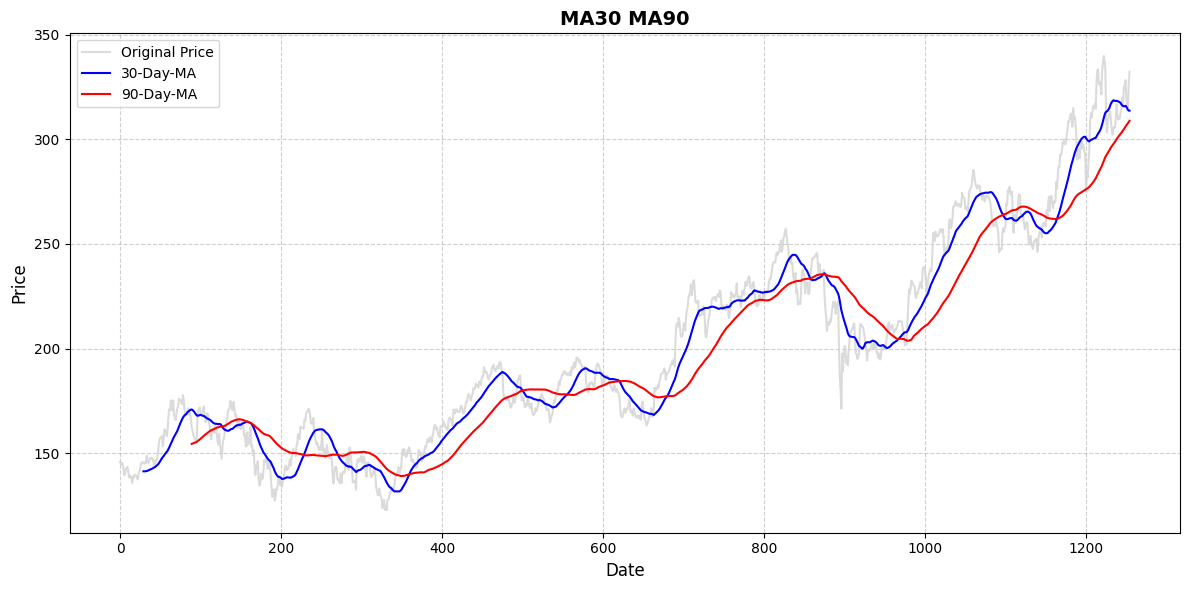

In [17]:
aapl = df[
    df["Ticker"] == "AAPL"
]

plt.figure(figsize=(12,6))

plt.plot(aapl["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(aapl["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(aapl["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

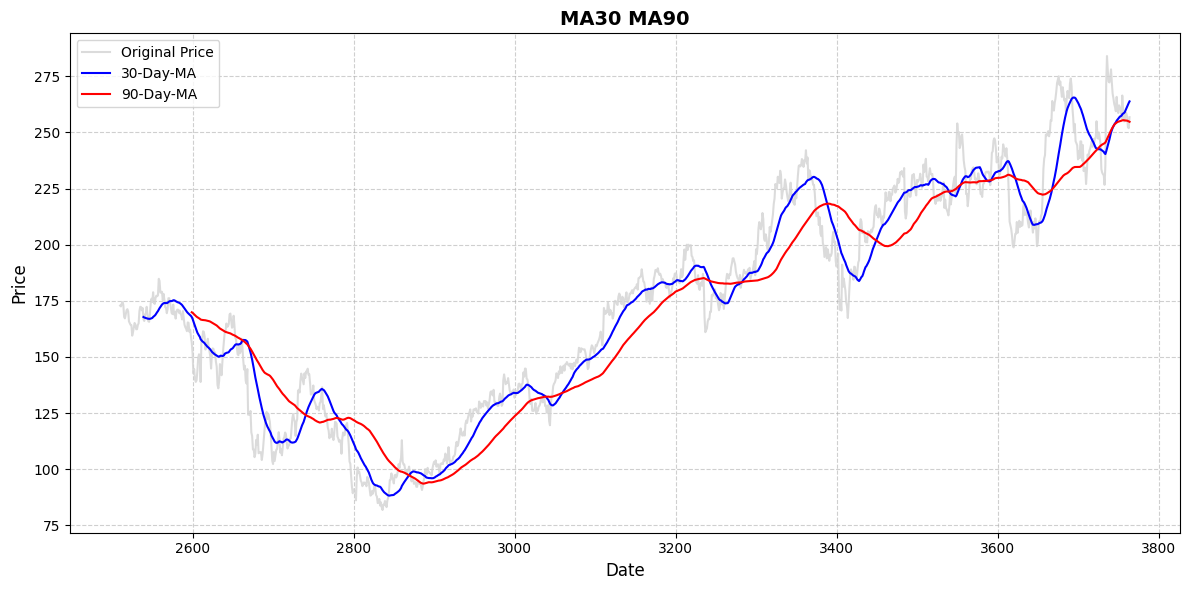

In [18]:
amzn = df[
    df["Ticker"] == "AMZN"
]

plt.figure(figsize=(12,6))

plt.plot(amzn["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(amzn["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(amzn["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

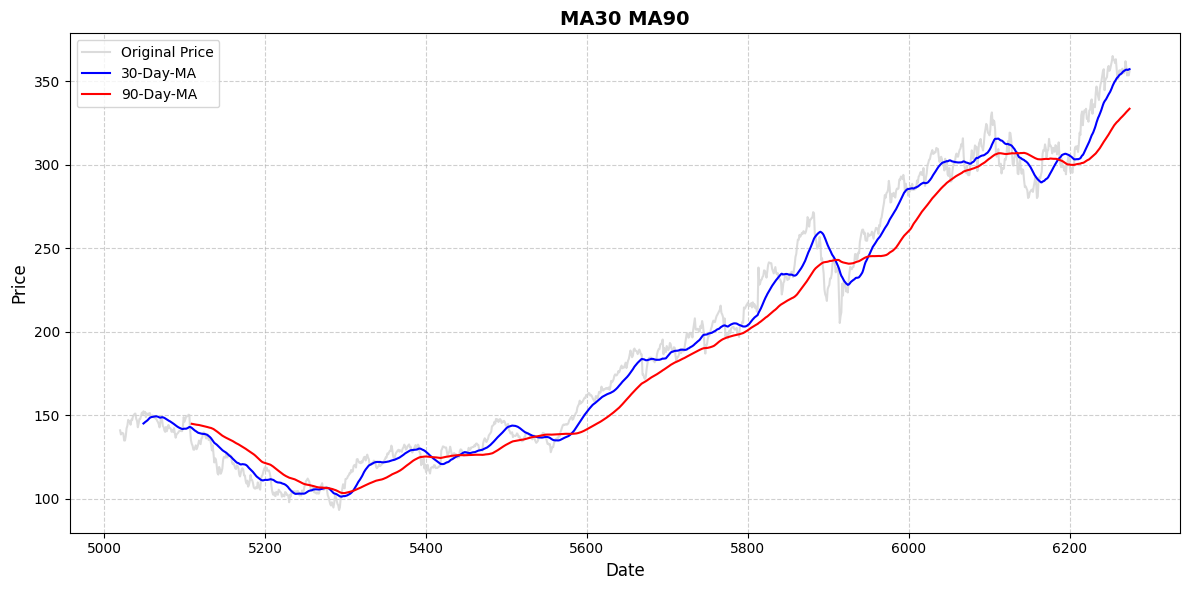

In [19]:
jpm = df[
    df["Ticker"] == "JPM"
]

plt.figure(figsize=(12,6))

plt.plot(jpm["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(jpm["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(jpm["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

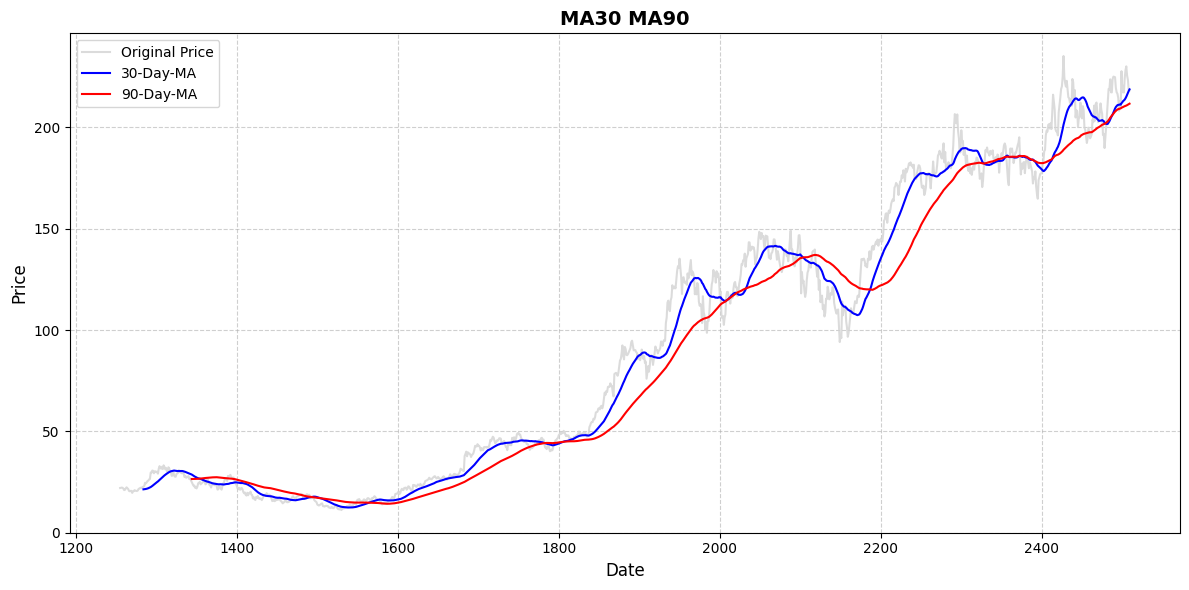

In [20]:
nvda = df[
    df["Ticker"] == "NVDA"
]

plt.figure(figsize=(12,6))

plt.plot(nvda["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(nvda["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(nvda["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

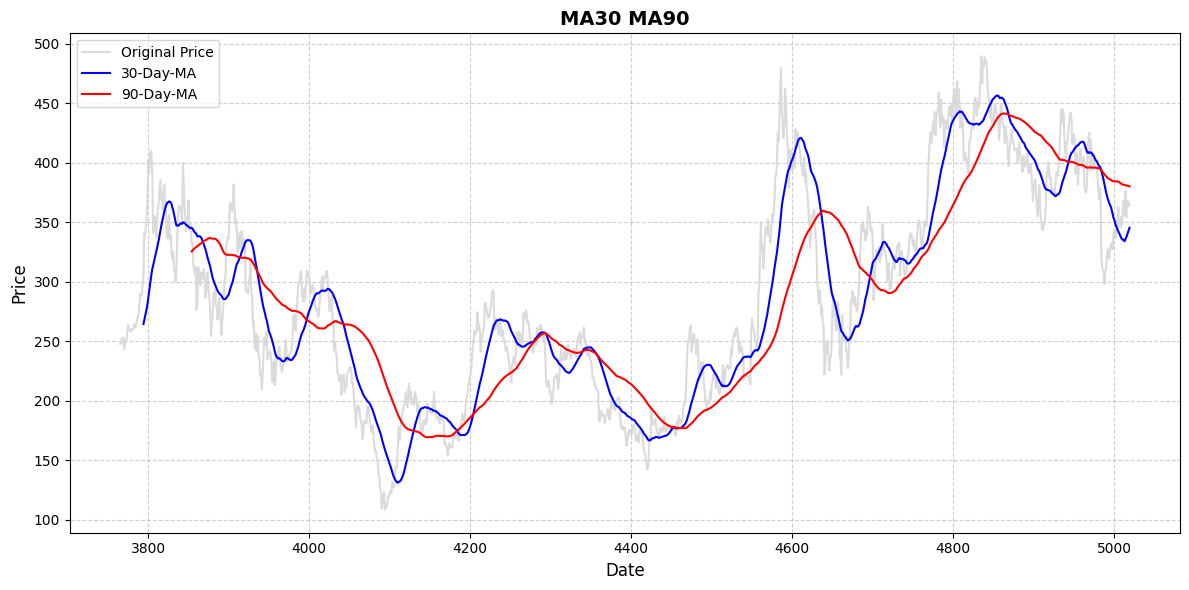

In [21]:
tsla = df[
    df["Ticker"] == "TSLA"
]

plt.figure(figsize=(12,6))

plt.plot(tsla["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(tsla["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(tsla["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

Question 5 — Best and worst days

In [22]:
best_days = {}
worst_days = {}

for ticker in daily_return.columns:

    best_days[ticker] = daily_return[ticker].nlargest(10)
    worst_days[ticker] = daily_return[ticker].nsmallest(10)

In [23]:
best_days["AAPL"]

date
2025-04-09    0.153289
2022-11-10    0.088974
2022-10-28    0.075553
2024-06-11    0.072649
2022-01-28    0.069777
2025-05-12    0.063146
2024-05-03    0.059816
2025-08-06    0.050907
2022-11-30    0.048594
2026-07-02    0.048407
Name: AAPL, dtype: float64

In [24]:
worst_days["AAPL"]

date
2025-04-03   -0.092456
2026-07-31   -0.073539
2025-04-04   -0.072887
2026-06-25   -0.061178
2022-09-13   -0.058679
2022-05-18   -0.056419
2022-05-05   -0.055716
2022-05-11   -0.051841
2026-02-12   -0.049982
2025-04-08   -0.049818
Name: AAPL, dtype: float64

In [25]:
best_days["AMZN"]

date
2026-07-31    0.153206
2022-02-04    0.135359
2022-11-10    0.121778
2025-04-09    0.119770
2022-07-29    0.103615
2025-10-31    0.095845
2023-08-04    0.082693
2025-05-12    0.080700
2024-02-02    0.078666
2023-02-02    0.073799
Name: AMZN, dtype: float64

In [26]:
worst_days["AMZN"]

date
2022-04-29   -0.140494
2025-04-03   -0.089791
2024-08-02   -0.087847
2023-02-03   -0.084315
2025-08-01   -0.082696
2022-02-03   -0.078128
2022-05-05   -0.075610
2022-05-18   -0.071562
2022-09-13   -0.070575
2022-10-28   -0.068042
Name: AMZN, dtype: float64

In [27]:
best_days["JPM"]

date
2024-11-06    0.115445
2025-04-09    0.080555
2023-04-14    0.075510
2022-05-23    0.061872
2022-10-13    0.055593
2022-10-21    0.052527
2022-10-04    0.046784
2022-07-15    0.045833
2022-03-16    0.044686
2024-10-11    0.044399
Name: JPM, dtype: float64

In [28]:
worst_days["JPM"]

date
2025-04-04   -0.074838
2025-04-03   -0.069685
2024-04-12   -0.064678
2022-01-14   -0.061463
2023-03-09   -0.054137
2024-09-10   -0.051889
2023-03-15   -0.047244
2025-12-09   -0.046636
2022-06-10   -0.045966
2024-05-20   -0.044973
Name: JPM, dtype: float64

In [29]:
best_days["NVDA"]

date
2023-05-25    0.243696
2025-04-09    0.187227
2024-02-22    0.164009
2022-11-10    0.143293
2023-02-23    0.140214
2024-07-31    0.128121
2021-11-04    0.120423
2022-03-24    0.098151
2022-05-13    0.094653
2024-05-23    0.093197
Name: NVDA, dtype: float64

In [30]:
worst_days["NVDA"]

date
2025-01-27   -0.169682
2024-04-19   -0.100046
2024-09-03   -0.095250
2022-09-13   -0.094726
2022-05-09   -0.092369
2022-08-26   -0.092279
2025-03-03   -0.086936
2025-02-27   -0.084781
2022-10-07   -0.080274
2022-06-13   -0.078178
Name: NVDA, dtype: float64

In [31]:
best_days["TSLA"]

date
2025-04-09    0.226900
2024-10-24    0.219190
2024-04-29    0.153069
2024-11-06    0.147510
2022-01-03    0.135317
2021-10-25    0.126616
2024-04-24    0.120611
2025-03-24    0.119336
2023-01-27    0.110002
2023-01-26    0.109673
Name: TSLA, dtype: float64

In [32]:
worst_days["TSLA"]

date
2025-03-10   -0.154262
2026-07-23   -0.145237
2025-06-05   -0.142599
2024-07-24   -0.123346
2023-01-03   -0.122422
2022-04-26   -0.121841
2024-01-25   -0.121253
2021-11-09   -0.119903
2022-01-27   -0.115542
2022-12-27   -0.114089
Name: TSLA, dtype: float64

Question 6 — Correlation

In [33]:
correlation = daily_return.corr()

correlation

,AAPL,AMZN,JPM,NVDA,TSLA
AAPL,1.000000,0.492804,0.362007,0.471657,0.461224
AMZN,0.492804,1.000000,0.354609,0.522945,0.435681
JPM,0.362007,0.354609,1.000000,0.324971,0.317999
NVDA,0.471657,0.522945,0.324971,1.000000,0.462091
TSLA,0.461224,0.435681,0.317999,0.462091,1.000000


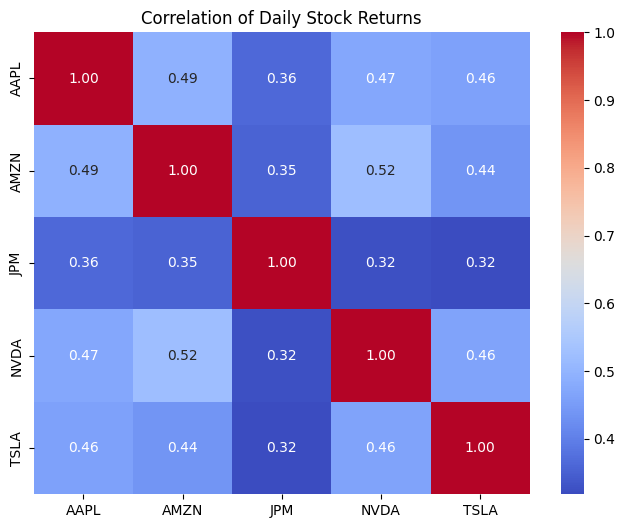

In [34]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Daily Stock Returns")

plt.show()

Question 7 — Risk vs Return

In [35]:
annual_return = daily_return.mean() * 252

In [36]:
annual_return

AAPL    0.204731
AMZN    0.145726
JPM     0.215979
NVDA    0.594897
TSLA    0.256770
dtype: float64

In [37]:
annual_volatility = daily_return.std() * np.sqrt(252)

In [38]:
risk_return = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

risk_return

,Annual Return,Annual Volatility
AAPL,0.204731,0.280798
AMZN,0.145726,0.364746
JPM,0.215979,0.244137
NVDA,0.594897,0.520340
TSLA,0.256770,0.598934


In [39]:
risk_return["Annual Return %"] = (
    risk_return["Annual Return"] * 100
)

risk_return["Annual Volatility %"] = (
    risk_return["Annual Volatility"] * 100
)

In [40]:
risk_return

,Annual Return,Annual Volatility,Annual Return %,Annual Volatility %
AAPL,0.204731,0.280798,20.473110,28.079824
AMZN,0.145726,0.364746,14.572583,36.474551
JPM,0.215979,0.244137,21.597919,24.413712
NVDA,0.594897,0.520340,59.489655,52.034043
TSLA,0.256770,0.598934,25.677011,59.893363


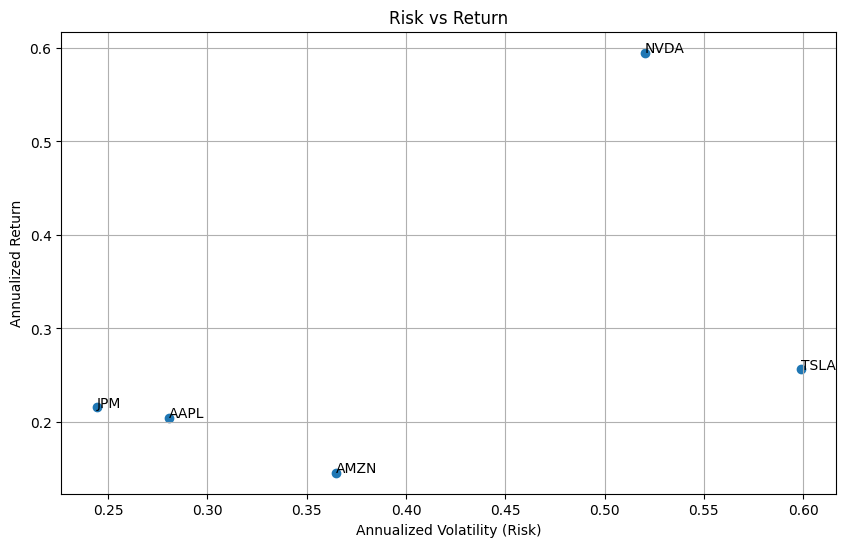

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_return["Annual Volatility"],
    risk_return["Annual Return"]
)

for ticker in risk_return.index:

    plt.annotate(
        ticker,
        (
            risk_return.loc[ticker, "Annual Volatility"],
            risk_return.loc[ticker, "Annual Return"]
        )
    )

plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.title("Risk vs Return")

plt.grid(True)

plt.show()

Extra Question — Risk Adjusted Return

In [42]:
risk_return["Risk Adjusted Return"] = risk_return["Annual Return"] / risk_return["Annual Volatility"]

In [45]:
df2 = df[["Date", "Open", "High", "Low", "Close", "Volume", "Ticker"]]
df2

Price,Date,Open,High,Low,Close,Volume,Ticker
0,2021-09-13,150.630005,151.419998,148.750000,149.550003,102404300,AAPL
1,2021-09-14,150.350006,151.070007,146.910004,148.119995,109296300,AAPL
2,2021-09-15,148.559998,149.440002,146.369995,149.029999,83281300,AAPL
3,2021-09-16,148.440002,148.970001,147.220001,148.789993,68034100,AAPL
4,2021-09-17,148.820007,148.820007,145.759995,146.059998,129868800,AAPL
...,...,...,...,...,...,...,...
6270,2026-09-04,361.000000,362.859985,355.200012,358.640015,4873500,JPM
6271,2026-09-08,357.100006,358.549988,353.230011,353.510010,5631400,JPM
6272,2026-09-09,352.000000,356.329987,348.690002,354.709991,6318200,JPM
6273,2026-09-10,353.510010,354.220001,351.119995,353.559998,4184200,JPM


In [48]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6275 non-null   datetime64[ns]
 1   Open    6275 non-null   float64       
 2   High    6275 non-null   float64       
 3   Low     6275 non-null   float64       
 4   Close   6275 non-null   float64       
 5   Volume  6275 non-null   int64         
 6   Ticker  6275 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 343.3+ KB


In [49]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30,MA90
0,2021-09-13,145.866745,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN,NaN,NaN
1,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL,NaN,NaN,NaN
2,2021-09-15,145.359528,149.029999,149.440002,146.369995,148.559998,83281300,AAPL,NaN,NaN,NaN
3,2021-09-16,145.125473,148.789993,148.970001,147.220001,148.440002,68034100,AAPL,NaN,NaN,NaN
4,2021-09-17,142.462677,146.059998,148.820007,145.759995,148.820007,129868800,AAPL,NaN,NaN,NaN


In [51]:
df2.isnull().sum()

Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64

In [52]:
df2.to_csv("stock_market_clean.csv", index=False)